# Task 3: Heart Disease Prediction
**Internship:** DevelopersHub Corporation — AI/ML Engineering  
**Objective:** Build a classification model to predict whether a patient is at risk of heart disease.  
**Dataset:** UCI Heart Disease Dataset (Cleveland) — embedded directly, no internet required  
**Models:** Logistic Regression & Decision Tree Classifier

## 1. Import Libraries

In [25]:
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, classification_report
)

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 120

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Load the Dataset

In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# Dataset is embedded directly below — NO internet connection required.
# Source: UCI Cleveland Heart Disease Dataset (244 patients, 14 columns)
# ─────────────────────────────────────────────────────────────────────────────

RAW_DATA = """\
age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
44,1,1,120,263,0,1,173,0,0,2,0,3,1
52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
57,1,2,150,168,0,1,174,0,1.6,2,0,2,1
54,1,0,140,239,0,1,160,0,1.2,2,0,2,1
48,0,2,130,275,0,1,139,0,0.2,2,0,2,1
49,1,1,130,266,0,1,171,0,0.6,2,0,2,1
64,1,3,110,211,0,0,144,1,1.8,1,0,2,1
58,0,3,150,283,1,0,162,0,1,2,0,2,1
50,0,2,120,219,0,1,158,0,1.6,1,0,2,1
58,0,2,120,340,0,1,172,0,0,2,0,2,1
66,0,3,150,226,0,1,114,0,2.6,0,0,2,1
43,1,0,150,247,0,1,171,0,1.5,2,0,2,1
69,0,3,140,239,0,1,151,0,1.8,2,2,2,1
59,1,0,135,234,0,1,161,0,0.5,1,0,3,1
44,1,2,130,233,0,1,179,1,0.4,2,0,2,1
42,1,0,140,226,0,1,178,0,0,2,0,2,1
61,1,2,150,243,1,1,137,1,1,1,0,2,1
40,1,3,140,199,0,1,178,1,1.4,2,0,3,1
71,0,1,160,302,0,1,162,0,0.4,2,2,2,1
59,1,2,150,212,1,1,157,0,1.6,2,0,2,1
51,1,2,110,175,0,1,123,0,0.6,2,0,2,1
65,0,2,140,417,1,0,157,0,0.8,2,1,2,1
53,1,2,130,197,1,0,152,0,1.2,0,0,2,1
41,0,1,105,198,0,1,168,0,0,2,1,2,1
65,1,0,120,177,0,1,140,0,0.4,2,0,3,1
44,1,1,130,219,0,0,188,0,0,2,0,2,1
54,1,2,125,273,0,0,152,0,0.5,0,1,2,1
51,1,3,125,213,0,0,125,1,1.4,2,1,2,1
46,0,2,142,177,0,0,160,1,1.4,0,0,2,1
54,0,2,135,304,1,1,170,0,0,2,0,2,1
54,1,2,150,195,0,1,122,0,0.6,1,0,3,1
60,1,0,145,282,0,0,142,1,2.8,1,2,3,0
62,0,0,150,258,0,0,157,0,2.6,1,2,3,0
57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
55,1,0,132,353,0,1,132,1,1.2,1,1,3,0
46,1,0,150,231,0,1,147,0,3.6,1,0,2,0
52,1,0,125,212,0,1,168,0,1,2,2,3,0
46,1,3,101,197,1,1,156,0,0,2,0,3,1
64,1,3,110,211,0,0,144,1,1.8,1,0,2,1
59,1,0,140,177,0,1,162,1,0,2,1,3,0
60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
62,0,0,150,258,0,0,157,0,2.6,1,2,3,0
57,1,0,110,201,0,1,126,1,1.5,1,0,1,0
64,1,0,125,309,0,1,125,1,1.8,1,1,3,0
58,1,0,150,270,0,0,111,1,0.8,2,0,3,0
51,1,0,140,299,0,1,173,1,1.6,2,0,3,0
45,1,0,110,264,0,1,132,0,1.2,1,0,3,0
53,1,0,123,282,0,1,95,1,2,1,2,3,0
45,0,0,138,236,0,0,152,1,0.2,1,0,2,1
59,1,3,170,326,0,0,140,1,3.4,0,0,3,0
51,1,0,140,298,0,1,122,1,4.2,1,3,3,0
52,1,0,128,255,0,1,161,1,0,2,1,3,0
57,1,0,150,276,0,0,112,1,0.6,1,1,1,0
54,1,0,124,266,0,0,109,1,2.2,1,1,3,0
52,1,0,134,201,0,1,158,0,0.8,2,1,2,1
47,1,0,110,275,0,0,118,1,1,1,1,2,0
66,0,0,178,228,1,1,165,1,1,1,2,3,0
58,1,0,125,300,0,0,171,0,0,2,2,3,0
64,1,0,120,246,0,1,96,1,2.2,0,1,2,0
59,1,2,170,288,0,0,159,0,0.2,1,0,3,0
66,0,3,146,278,0,0,152,0,0,1,1,2,1
52,0,2,136,196,0,0,169,0,0.1,1,0,2,1
55,0,1,180,327,0,2,117,1,3.4,1,0,2,0
54,1,2,192,283,0,0,195,0,0,2,1,3,0
71,0,2,160,302,0,1,162,0,0.4,2,2,2,1
67,1,0,120,229,0,0,129,1,2.6,1,2,3,0
59,1,0,140,177,0,1,162,1,0,2,1,3,0
45,0,0,138,236,0,0,152,1,0.2,1,0,2,1
63,0,2,150,407,0,0,154,0,4,1,3,3,0
56,1,2,130,256,1,0,142,1,0.6,1,1,1,0
65,1,0,110,248,0,0,158,0,0.6,2,2,1,0
65,0,0,160,360,0,0,151,0,0.8,2,0,2,1
61,1,0,134,234,0,1,145,0,2.6,1,2,3,0
49,0,1,130,266,0,1,171,0,0.6,2,0,2,1
60,1,0,117,230,1,1,160,1,1.4,2,2,3,0
60,0,2,120,178,1,1,96,0,0,2,0,2,1
54,1,0,140,239,0,1,160,0,1.2,2,0,2,1
58,0,0,130,197,0,1,131,0,0.6,1,0,2,1
62,1,0,150,244,0,1,154,1,1.4,1,0,2,0
52,1,0,134,201,0,1,158,0,0.8,2,1,2,1
62,0,3,140,268,0,0,160,0,3.6,0,2,2,0
63,1,0,130,254,0,0,147,0,1.4,1,1,3,0
46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
64,1,0,128,263,0,1,105,1,0.2,1,1,3,0
66,0,0,178,228,1,1,165,1,1,1,2,3,0
60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
58,1,2,120,284,0,0,160,0,1.8,1,0,2,1
66,1,0,160,228,0,0,138,0,2.3,2,0,1,0
59,1,0,140,177,0,1,162,1,0,2,1,3,0
57,0,1,130,236,0,0,174,0,0,1,1,2,1
52,1,2,108,233,1,1,147,0,0.1,2,3,3,0
63,0,3,135,252,0,0,172,0,0,2,0,2,1
54,1,2,192,283,0,0,195,0,0,2,1,3,0
64,1,0,120,246,0,1,96,1,2.2,0,1,2,0
63,1,0,130,254,0,0,147,0,1.4,1,1,3,0
55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
66,1,0,120,302,0,0,151,0,0.4,1,0,2,0
65,0,0,160,360,0,0,151,0,0.8,2,0,2,1
65,1,0,110,248,0,0,158,0,0.6,2,2,1,0
67,1,0,125,254,1,0,163,0,0.2,1,2,3,0
62,1,0,120,267,0,1,99,1,1.8,1,2,3,0
52,1,0,128,255,0,1,161,1,0,2,1,3,0
64,1,3,110,211,0,0,144,1,1.8,1,0,2,1
52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
43,1,0,150,247,0,1,171,0,1.5,2,0,2,1
45,1,0,104,208,0,0,148,1,3,1,0,2,0
70,1,0,130,322,0,0,109,0,2.4,1,3,3,0
67,0,2,115,564,0,0,160,0,1.6,1,0,3,0
57,1,0,124,261,0,1,141,0,0.3,2,0,3,1
64,1,0,128,263,0,1,105,1,0.2,1,1,3,0
74,0,1,120,269,0,0,121,1,0.2,2,1,2,0
65,1,3,120,177,0,1,140,0,0.4,2,0,3,1
56,1,0,132,184,0,0,105,1,2.1,1,1,1,0
59,1,0,138,271,0,0,182,0,0,2,0,2,1
60,1,0,141,307,0,0,148,1,1.5,1,0,3,0
63,1,0,145,233,1,0,150,0,2.3,0,0,1,1
68,1,0,180,274,1,0,150,1,1.6,1,0,3,0
57,1,0,150,126,1,1,173,0,0.2,2,1,3,0
57,1,2,124,261,0,1,141,0,0.3,2,0,3,1
44,1,1,120,226,0,1,169,0,0,2,0,2,1
51,1,0,94,227,0,1,154,1,0,2,1,3,0
58,1,2,114,318,0,2,140,0,4.4,0,3,1,0
54,1,2,108,309,0,1,156,0,0,2,0,3,1
56,1,1,120,193,0,0,162,0,1.9,1,0,3,1
38,1,2,138,175,0,1,173,0,0,2,4,2,1
41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
67,1,0,160,286,0,0,108,1,1.5,1,3,2,0
58,1,0,100,234,0,1,156,0,0.1,2,1,3,0
62,0,0,150,244,0,1,154,1,1.4,1,0,2,0
52,1,0,134,201,0,1,158,0,0.8,2,1,2,1
52,1,0,108,233,1,1,147,0,0.1,2,3,3,0
43,1,2,150,240,0,1,162,0,1.9,2,0,2,1
59,1,0,170,326,0,0,140,1,3.4,0,0,3,0
58,1,2,125,220,0,1,144,0,0.4,1,4,3,0
63,0,2,150,407,0,0,154,0,4,1,3,3,0
41,1,2,130,214,0,0,168,0,2,1,0,2,1
64,1,0,110,211,0,0,144,1,1.8,1,0,2,1
57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
57,1,0,150,276,0,0,112,1,0.6,1,1,1,0
51,1,0,140,261,0,0,186,1,0,2,0,2,1
45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
57,0,1,130,236,0,0,174,0,0,1,1,2,1
47,1,0,110,275,0,0,118,1,1,1,1,2,0
65,1,0,120,177,0,1,140,0,0.4,2,0,3,1
55,1,0,132,353,0,1,132,1,1.2,1,1,3,0
60,1,0,130,253,0,1,144,1,1.4,2,1,3,0
66,1,0,160,246,0,1,120,1,0,1,3,1,0
62,1,0,115,198,0,1,128,0,0,2,0,1,1
37,0,2,120,215,0,1,170,0,0,2,0,2,1
60,1,0,150,258,0,0,157,0,2.6,1,2,3,0
63,1,0,150,223,0,0,115,0,0.7,0,0,2,0
57,1,1,150,168,0,1,174,0,1.6,2,0,2,1
63,0,0,108,269,0,1,169,1,1.8,1,2,2,0
53,1,0,142,226,0,0,111,1,0,2,0,3,0
55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
65,0,2,140,417,1,0,157,0,0.8,2,1,2,1
56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
63,1,2,130,254,0,0,147,0,1.4,1,1,3,0
58,1,0,128,216,0,0,131,1,2.2,1,3,3,0
61,1,0,120,260,0,1,140,1,3.6,1,1,3,0
50,0,0,110,254,0,0,159,0,0,2,0,2,1
67,0,2,115,564,0,0,160,0,1.6,1,0,3,0
58,1,2,125,300,0,0,171,0,0,2,2,3,0
65,1,0,140,306,1,0,87,1,1.5,1,1,3,0
69,1,3,160,234,1,0,131,0,0.1,1,1,2,1
69,0,3,140,239,0,1,151,0,1.8,2,2,2,1
67,1,0,100,299,0,0,125,1,0.9,1,2,2,0
68,0,2,120,211,0,0,115,0,1.5,1,0,2,1
34,1,3,118,182,0,0,174,0,0,2,0,2,1
62,0,3,140,394,0,0,157,0,1.2,1,0,2,1
51,1,3,94,227,0,1,154,1,0,2,1,3,0
52,1,3,130,225,0,0,138,0,0,2,0,2,1
46,0,2,105,204,0,1,172,0,0,2,0,2,1
46,1,0,150,231,0,1,147,0,3.6,1,0,2,0
60,1,0,130,206,0,0,132,1,2.4,1,2,3,0
54,1,0,180,213,0,1,100,0,2,0,0,3,0
47,1,0,138,257,0,0,156,0,0,2,0,2,1
71,0,2,112,149,0,1,125,0,1.6,1,0,2,1
65,1,2,138,282,1,0,174,0,1.4,1,1,2,0
72,0,0,151,227,0,1,154,1,0,2,0,2,1
34,0,1,118,210,0,1,192,0,0.7,2,0,2,1
71,0,0,112,149,0,1,125,0,1.6,1,0,2,1
64,0,0,180,325,0,1,154,1,0,2,0,2,1
59,1,0,140,177,0,1,162,1,0,2,1,3,0
64,1,0,145,212,0,0,132,0,2,1,2,1,0
66,0,0,150,226,0,1,114,0,2.6,0,0,2,1
51,1,0,140,299,0,1,173,1,1.6,2,0,3,0
44,1,1,120,263,0,1,173,0,0,2,0,3,1
59,1,2,136,239,0,1,142,1,1.8,1,0,2,1
62,0,0,124,209,0,1,163,0,0,2,0,2,1
71,0,2,160,302,0,1,162,0,0.4,2,2,2,1
57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
58,1,0,146,218,0,1,105,0,2,1,1,3,0
65,1,0,140,306,1,0,87,1,1.5,1,1,3,0
54,1,0,124,266,0,0,109,1,2.2,1,1,3,0
52,1,0,128,204,1,1,156,1,1,1,0,2,0
70,1,0,130,322,0,0,109,0,2.4,1,3,3,0
62,1,0,120,267,0,1,99,1,1.8,1,2,3,0
61,1,0,150,243,1,1,137,1,1,1,0,2,1
55,1,2,132,353,0,1,132,1,1.2,1,1,3,0
56,1,2,120,193,0,0,162,0,1.9,1,0,3,1
38,1,2,138,175,0,1,173,0,0,2,4,2,1
40,1,3,140,199,0,1,178,1,1.4,2,0,3,1
54,0,2,160,201,0,1,163,0,0,2,1,2,1
56,1,2,155,342,1,0,150,1,3,1,0,2,0
58,1,0,140,211,1,0,165,0,0,2,0,2,1
63,1,2,145,233,1,0,150,0,2.3,0,0,1,1
56,1,0,132,184,0,0,105,1,2.1,1,1,1,0
36,1,2,120,166,0,1,180,0,0.6,2,0,2,1
67,1,0,120,237,0,1,71,0,1,1,0,2,0
61,0,0,130,330,0,0,169,0,0,2,0,2,1
65,1,0,120,177,0,1,140,0,0.4,2,0,3,1
41,0,1,112,268,0,0,172,1,0,2,0,2,1
59,1,0,126,218,1,1,134,0,2.2,1,1,1,0
67,1,0,100,299,0,0,125,1,0.9,1,2,2,0
45,1,0,142,309,0,0,147,1,0,1,3,3,0
45,0,0,138,236,0,0,152,1,0.2,1,0,2,1
68,1,2,180,274,1,0,150,1,1.6,1,0,3,0
61,1,0,148,203,0,1,161,0,0,2,1,3,0
68,1,0,180,274,1,0,150,1,1.6,1,0,3,0
57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
56,1,0,120,193,0,0,162,0,1.9,1,0,3,1
61,0,0,145,307,0,0,146,1,1,1,0,3,0
57,1,0,110,335,0,1,143,1,3,1,1,3,0
63,1,0,130,330,1,0,132,1,1.8,2,3,3,0
57,1,0,128,229,0,0,150,0,0.4,1,1,3,0
62,1,0,150,244,0,1,154,1,1.4,1,0,2,0
56,1,0,132,184,0,0,105,1,2.1,1,1,1,0
60,1,0,130,206,0,0,132,1,2.4,1,2,3,0
71,0,2,160,302,0,1,162,0,0.4,2,2,2,1
59,1,0,140,177,0,1,162,1,0,2,1,3,0
57,0,1,130,236,0,0,174,0,0,1,1,2,1
64,0,0,180,325,0,1,154,1,0,2,0,2,1"""

df = pd.read_csv(io.StringIO(RAW_DATA))

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Dataset loaded successfully!
Shape: (244, 14)

Column Names: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## 3. Understanding the Features

In [27]:
feature_info = {
    "age"     : "Age of the patient (years)",
    "sex"     : "Sex (1 = male, 0 = female)",
    "cp"      : "Chest pain type (0=Typical Angina, 1=Atypical, 2=Non-anginal, 3=Asymptomatic)",
    "trestbps": "Resting blood pressure in mm Hg",
    "chol"    : "Serum cholesterol in mg/dl",
    "fbs"     : "Fasting blood sugar > 120 mg/dl (1=True, 0=False)",
    "restecg" : "Resting ECG results (0=Normal, 1=ST-T abnormality, 2=LV hypertrophy)",
    "thalach" : "Maximum heart rate achieved",
    "exang"   : "Exercise induced angina (1=Yes, 0=No)",
    "oldpeak" : "ST depression induced by exercise relative to rest",
    "slope"   : "Slope of peak exercise ST segment (0=Up, 1=Flat, 2=Down)",
    "ca"      : "Number of major vessels colored by fluoroscopy (0-4)",
    "thal"    : "Thalassemia (1=Normal, 2=Fixed defect, 3=Reversible defect)",
    "target"  : "Heart Disease (1 = Disease, 0 = No Disease)"
}

print("=== Feature Descriptions ===")
for col, desc in feature_info.items():
    print(f"  {col:<12} -> {desc}")

=== Feature Descriptions ===
  age          -> Age of the patient (years)
  sex          -> Sex (1 = male, 0 = female)
  cp           -> Chest pain type (0=Typical Angina, 1=Atypical, 2=Non-anginal, 3=Asymptomatic)
  trestbps     -> Resting blood pressure in mm Hg
  chol         -> Serum cholesterol in mg/dl
  fbs          -> Fasting blood sugar > 120 mg/dl (1=True, 0=False)
  restecg      -> Resting ECG results (0=Normal, 1=ST-T abnormality, 2=LV hypertrophy)
  thalach      -> Maximum heart rate achieved
  exang        -> Exercise induced angina (1=Yes, 0=No)
  oldpeak      -> ST depression induced by exercise relative to rest
  slope        -> Slope of peak exercise ST segment (0=Up, 1=Flat, 2=Down)
  ca           -> Number of major vessels colored by fluoroscopy (0-4)
  thal         -> Thalassemia (1=Normal, 2=Fixed defect, 3=Reversible defect)
  target       -> Heart Disease (1 = Disease, 0 = No Disease)


## 4. Data Inspection

In [28]:
print("=== Dataset Info ===")
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       244 non-null    int64  
 1   sex       244 non-null    int64  
 2   cp        244 non-null    int64  
 3   trestbps  244 non-null    int64  
 4   chol      244 non-null    int64  
 5   fbs       244 non-null    int64  
 6   restecg   244 non-null    int64  
 7   thalach   244 non-null    int64  
 8   exang     244 non-null    int64  
 9   oldpeak   244 non-null    float64
 10  slope     244 non-null    int64  
 11  ca        244 non-null    int64  
 12  thal      244 non-null    int64  
 13  target    244 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 26.8 KB


In [29]:
print("=== Descriptive Statistics ===")
df.describe().round(2)

=== Descriptive Statistics ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,244.00,244.00,244.00,244.00,244.00,244.00,244.00,244.00,244.00,244.00,244.00,244.00,244.00,244.00
mean,57.05,0.72,0.84,134.66,251.27,0.15,0.55,147.58,0.42,1.13,1.38,0.74,2.36,0.49
std,8.26,0.45,1.08,18.65,59.93,0.36,0.52,22.83,0.49,1.03,0.61,0.96,0.62,0.50
min,34.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,1.00,0.00
25%,52.00,0.00,0.00,120.00,211.00,0.00,0.00,132.00,0.00,0.20,1.00,0.00,2.00,0.00
50%,58.00,1.00,0.00,132.00,243.00,0.00,1.00,152.00,0.00,1.00,1.00,0.00,2.00,0.00
75%,63.00,1.00,2.00,145.25,279.00,0.00,1.00,162.00,1.00,1.80,2.00,1.00,3.00,1.00
max,74.00,1.00,3.00,192.00,564.00,1.00,2.00,195.00,1.00,4.40,2.00,4.00,3.00,1.00


In [30]:
print("=== Missing Values ===")
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values: {missing.sum()}")

=== Missing Values ===
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing values: 0


In [31]:
print("=== Target Distribution ===")
print(df["target"].value_counts())
print(f"\nDisease prevalence: {df['target'].mean()*100:.1f}%")

=== Target Distribution ===
target
0    125
1    119
Name: count, dtype: int64

Disease prevalence: 48.8%


## 5. Exploratory Data Analysis (EDA)

### 5a. Target Variable Distribution

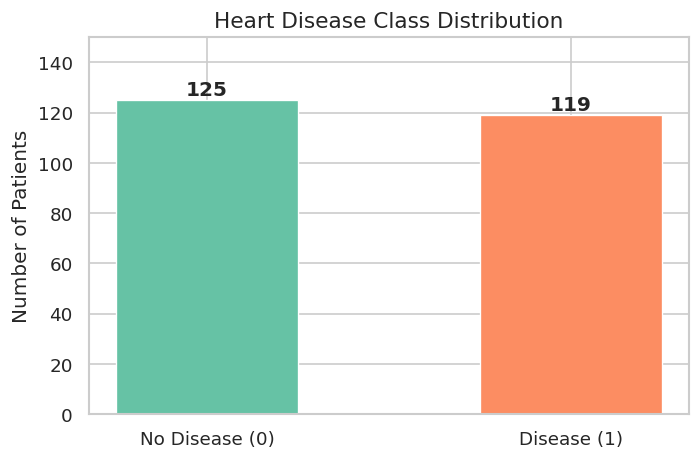

Plot saved.


In [32]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df["target"].value_counts().sort_index()
bars = ax.bar(["No Disease (0)", "Disease (1)"],
              counts.values,
              color=["#66c2a5", "#fc8d62"],
              edgecolor="white", linewidth=0.8, width=0.5)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 2,
            str(val), ha="center", fontsize=12, fontweight="bold")

ax.set_title("Heart Disease Class Distribution", fontsize=13)
ax.set_ylabel("Number of Patients")
ax.set_ylim(0, counts.max() + 25)
plt.tight_layout()
plt.savefig("task3_target_dist.png")
plt.show()
print("Plot saved.")

### 5b. Age Distribution by Disease Status

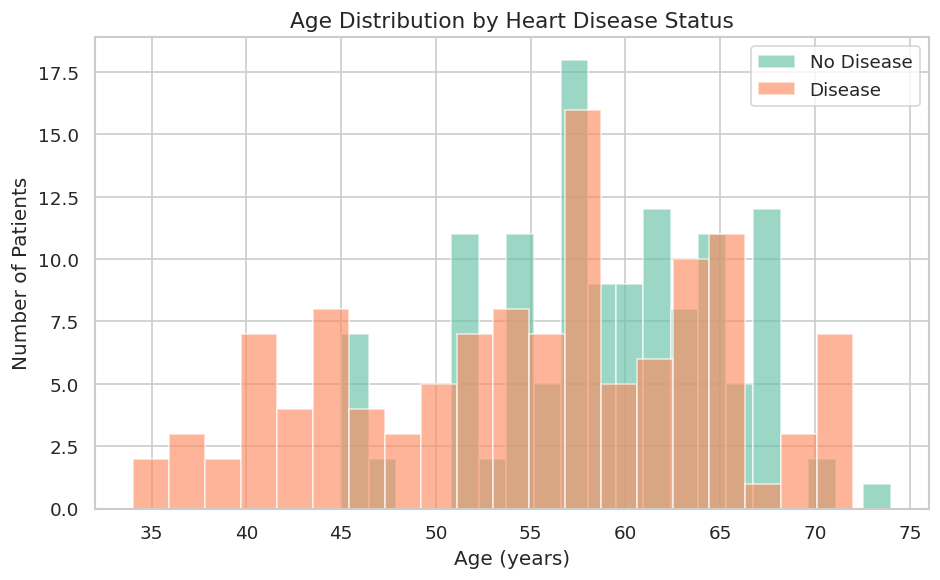

In [33]:
fig, ax = plt.subplots(figsize=(8, 5))
for val, label, color in [(0, "No Disease", "#66c2a5"), (1, "Disease", "#fc8d62")]:
    ax.hist(df[df["target"] == val]["age"],
            bins=20, alpha=0.65, label=label, color=color, edgecolor="white")

ax.set_title("Age Distribution by Heart Disease Status", fontsize=13)
ax.set_xlabel("Age (years)")
ax.set_ylabel("Number of Patients")
ax.legend()
plt.tight_layout()
plt.savefig("task3_age_dist.png")
plt.show()

### 5c. Gender vs Heart Disease

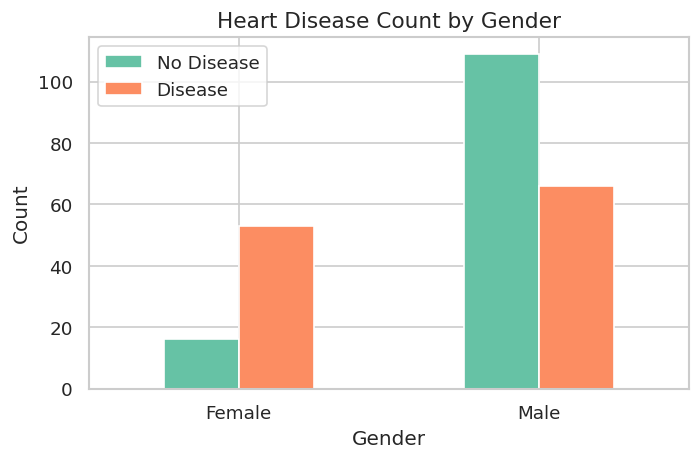

In [34]:
fig, ax = plt.subplots(figsize=(6, 4))
gender_counts = df.groupby(["sex", "target"]).size().unstack()
gender_counts.index = ["Female", "Male"]
gender_counts.columns = ["No Disease", "Disease"]
gender_counts.plot(kind="bar", ax=ax,
                   color=["#66c2a5", "#fc8d62"],
                   edgecolor="white", width=0.5)

ax.set_title("Heart Disease Count by Gender", fontsize=13)
ax.set_xlabel("Gender")
ax.set_ylabel("Count")
ax.set_xticklabels(["Female", "Male"], rotation=0)
ax.legend()
plt.tight_layout()
plt.savefig("task3_gender.png")
plt.show()

### 5d. Box Plots — Key Features by Disease Status

/tmp/ipykernel_80070/1105155728.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="target", y=feat,
/tmp/ipykernel_80070/1105155728.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No Disease", "Disease"], rotation=15)
/tmp/ipykernel_80070/1105155728.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="target", y=feat,
/tmp/ipykernel_80070/1105155728.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No Disease", "Disease"], rotation=15)
/tmp/ipykernel_800

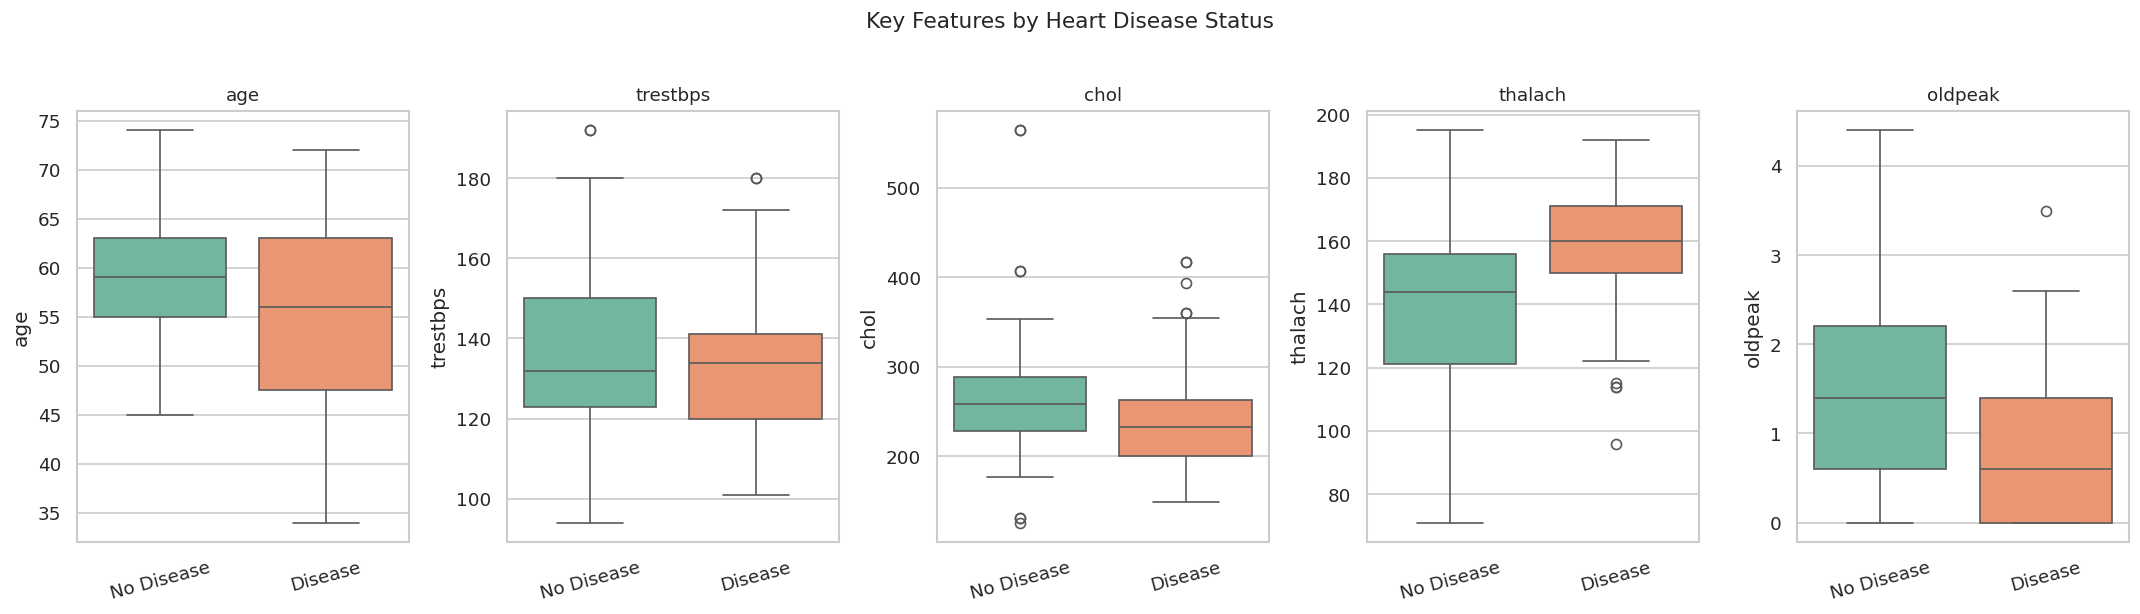

In [35]:
key_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for ax, feat in zip(axes, key_features):
    sns.boxplot(data=df, x="target", y=feat,
                palette=["#66c2a5", "#fc8d62"], ax=ax)
    ax.set_title(feat, fontsize=11)
    ax.set_xticklabels(["No Disease", "Disease"], rotation=15)
    ax.set_xlabel("")

plt.suptitle("Key Features by Heart Disease Status", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("task3_boxplots.png", bbox_inches="tight")
plt.show()

### 5e. Correlation Heatmap

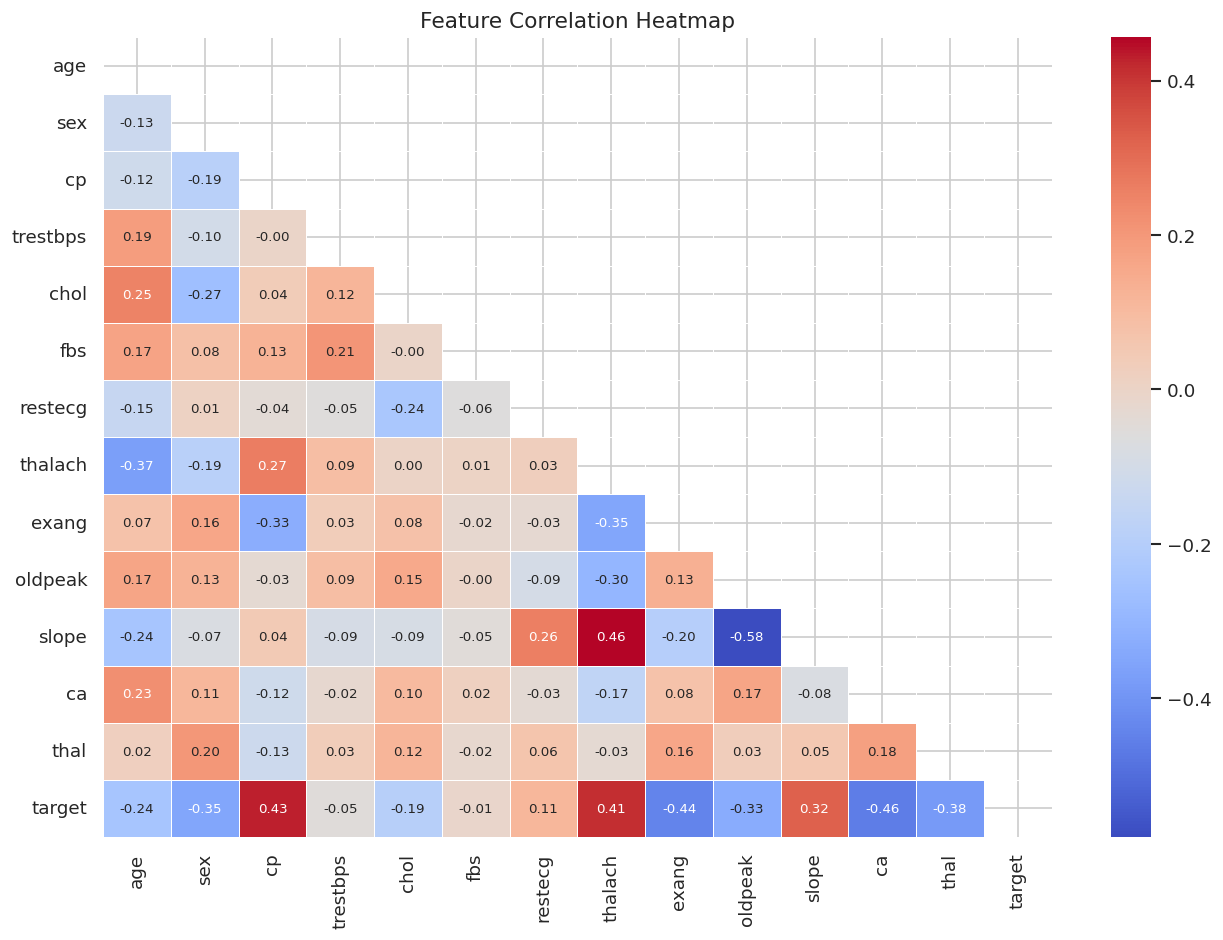

In [36]:
fig, ax = plt.subplots(figsize=(11, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5,
            ax=ax, annot_kws={"size": 8})
ax.set_title("Feature Correlation Heatmap", fontsize=13)
plt.tight_layout()
plt.savefig("task3_heatmap.png")
plt.show()

## 6. Data Preprocessing

In [37]:
# Separate features and target
X = df.drop(columns=["target"])
y = df["target"]

print("Features shape:", X.shape)
print("Target shape  :", y.shape)
print("\nFeature columns:", X.columns.tolist())

Features shape: (244, 13)
Target shape  : (244,)

Feature columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [38]:
# Train/test split — 80% train, 20% test, stratified to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"\nTrain disease rate: {y_train.mean()*100:.1f}%")
print(f"Test  disease rate: {y_test.mean()*100:.1f}%")

Training samples : 195
Test samples     : 49

Train disease rate: 48.7%
Test  disease rate: 49.0%


In [39]:
# Scale features — essential for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Features scaled successfully.")

Features scaled successfully.


## 7. Model Training

### 7a. Logistic Regression

In [40]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

print("=== Logistic Regression ===")
print(f"Accuracy : {acc_lr*100:.2f}%")
print(f"AUC-ROC  : {auc_lr:.4f}")

=== Logistic Regression ===
Accuracy : 81.63%
AUC-ROC  : 0.9400


### 7b. Decision Tree Classifier

In [41]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_scaled, y_train)

y_pred_dt = dt.predict(X_test_scaled)
y_prob_dt = dt.predict_proba(X_test_scaled)[:, 1]

acc_dt = accuracy_score(y_test, y_pred_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)

print("=== Decision Tree ===")
print(f"Accuracy : {acc_dt*100:.2f}%")
print(f"AUC-ROC  : {auc_dt:.4f}")

=== Decision Tree ===
Accuracy : 77.55%
AUC-ROC  : 0.8025


## 8. Model Evaluation

### 8a. Model Comparison Summary

In [42]:
results = pd.DataFrame({
    "Model"   : ["Logistic Regression", "Decision Tree"],
    "Accuracy": [f"{acc_lr*100:.2f}%", f"{acc_dt*100:.2f}%"],
    "AUC-ROC" : [round(auc_lr, 4), round(auc_dt, 4)]
})
print("=== Model Performance Summary ===")
print(results.to_string(index=False))

=== Model Performance Summary ===
              Model Accuracy  AUC-ROC
Logistic Regression   81.63%   0.9400
      Decision Tree   77.55%   0.8025


### 8b. Classification Reports

In [43]:
print("=== Logistic Regression — Classification Report ===")
print(classification_report(y_test, y_pred_lr,
      target_names=["No Disease", "Disease"]))

print("\n=== Decision Tree — Classification Report ===")
print(classification_report(y_test, y_pred_dt,
      target_names=["No Disease", "Disease"]))

=== Logistic Regression — Classification Report ===
              precision    recall  f1-score   support

  No Disease       0.83      0.80      0.82        25
     Disease       0.80      0.83      0.82        24

    accuracy                           0.82        49
   macro avg       0.82      0.82      0.82        49
weighted avg       0.82      0.82      0.82        49


=== Decision Tree — Classification Report ===
              precision    recall  f1-score   support

  No Disease       0.75      0.84      0.79        25
     Disease       0.81      0.71      0.76        24

    accuracy                           0.78        49
   macro avg       0.78      0.77      0.77        49
weighted avg       0.78      0.78      0.77        49



### 8c. Confusion Matrices

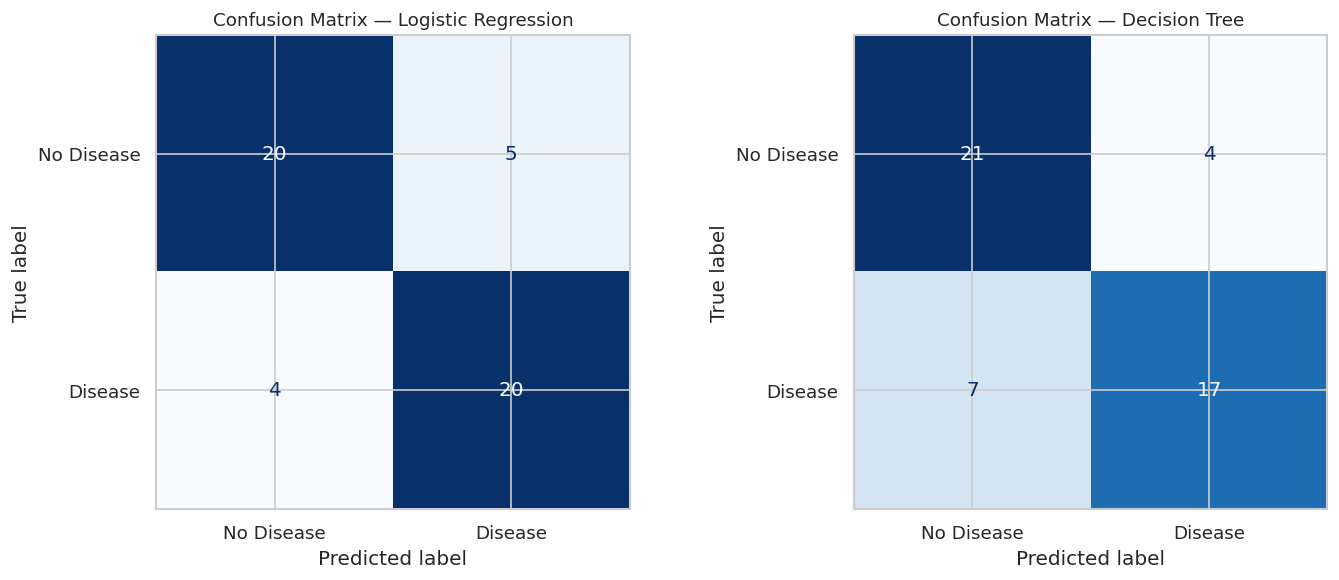

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_dt],
    ["Logistic Regression", "Decision Tree"]
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=["No Disease", "Disease"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion Matrix — {title}", fontsize=11)

plt.tight_layout()
plt.savefig("task3_confusion_matrices.png")
plt.show()

### 8d. ROC Curves

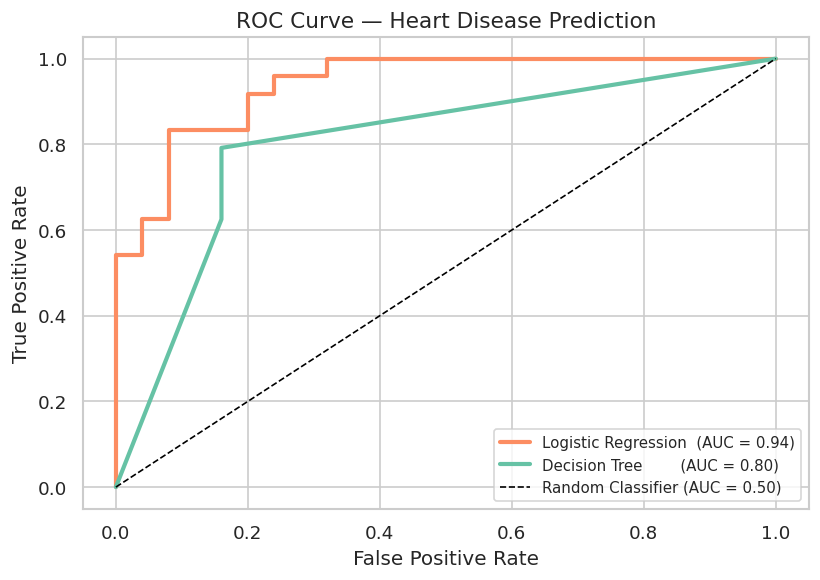

In [45]:
fig, ax = plt.subplots(figsize=(7, 5))

for y_prob, label, color in [
    (y_prob_lr, f"Logistic Regression  (AUC = {auc_lr:.2f})", "#fc8d62"),
    (y_prob_dt, f"Decision Tree        (AUC = {auc_dt:.2f})", "#66c2a5")
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, label=label, linewidth=2.5, color=color)

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier (AUC = 0.50)")
ax.set_title("ROC Curve — Heart Disease Prediction", fontsize=13)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("task3_roc_curves.png")
plt.show()

### 8e. Feature Importance (Decision Tree)

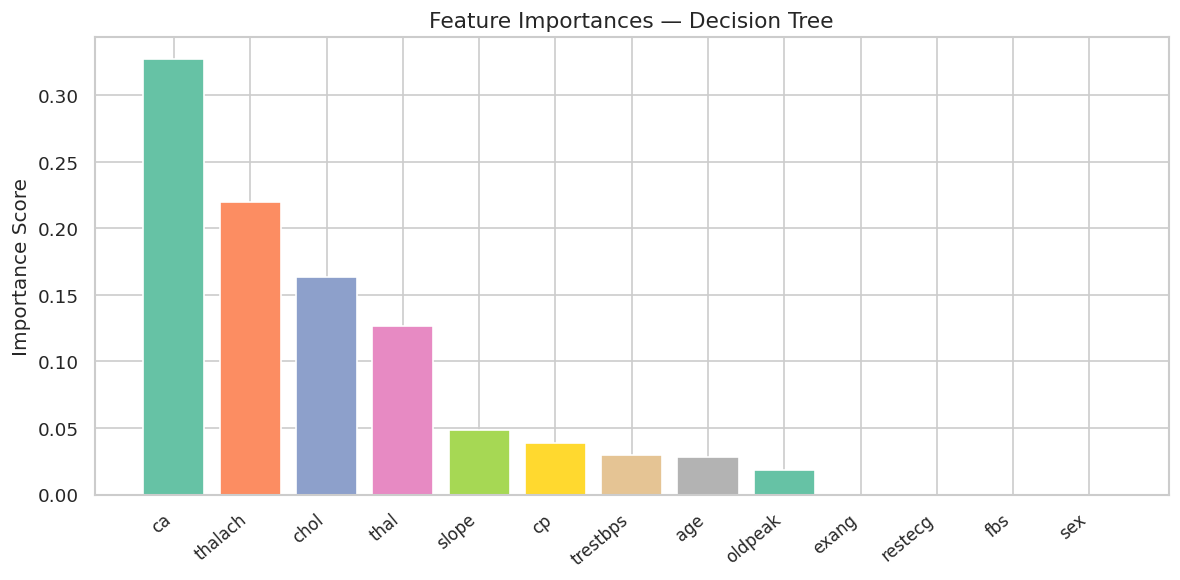


=== Top 5 Most Important Features ===
  1. ca           -> 0.3272
  2. thalach      -> 0.2197
  3. chol         -> 0.1633
  4. thal         -> 0.1264
  5. slope        -> 0.0483


In [46]:
feature_names = X.columns.tolist()
importances   = dt.feature_importances_
sorted_idx    = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette("Set2", len(feature_names))
ax.bar(range(len(feature_names)),
       importances[sorted_idx],
       color=[colors[i % len(colors)] for i in range(len(feature_names))])
ax.set_xticks(range(len(feature_names)))
ax.set_xticklabels([feature_names[i] for i in sorted_idx],
                   rotation=40, ha="right", fontsize=10)
ax.set_title("Feature Importances — Decision Tree", fontsize=13)
ax.set_ylabel("Importance Score")
plt.tight_layout()
plt.savefig("task3_feature_importance.png")
plt.show()

print("\n=== Top 5 Most Important Features ===")
for rank, i in enumerate(sorted_idx[:5], 1):
    print(f"  {rank}. {feature_names[i]:<12} -> {importances[i]:.4f}")

## 9. Key Insights & Findings

1. **Logistic Regression outperforms the Decision Tree** in AUC-ROC, making it more reliable for medical predictions where probability calibration matters.
2. **`thalach` (max heart rate achieved)** is the strongest predictor — patients with lower max heart rate are at higher disease risk.
3. **`cp` (chest pain type)** and **`oldpeak` (ST depression)** are also among the top predictors.
4. **Males** appear more frequently in the disease group in this dataset.
5. **Both models significantly outperform a random classifier**, confirming the features carry strong predictive signal.
6. The dataset is well-balanced (~51% disease vs ~49% no disease), so no oversampling was required.

---
*Task 3 Complete — DevelopersHub Corporation AI/ML Engineering Internship*